# Importing Libraries

In [1]:
import os
import time
import random

import torch
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

from diffusers import StableDiffusionPipeline
from codecarbon import EmissionsTracker

print("All printed succesfully")

c:\Users\ittis\OneDrive\Desktop\406 shit\carbon_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All printed succesfully


# Hardware Information


In [ ]:
print("=" * 50)

print(f"PyTorch Version : {torch.__version__}")

print(f"CUDA Available : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name : {torch.cuda.get_device_name(0)}")
    print(f"GPU Count : {torch.cuda.device_count()}")
else:
    print("Running on CPU")

print("=" * 50)

PyTorch Version : 2.11.0+cu128
CUDA Available : True
GPU Name : NVIDIA GeForce RTX 3060
GPU Count : 1


# Project Structure

In [2]:
PROJECT_DIR = "CarbonAwareTextToImage"

CPU_IMAGE_DIR = os.path.join(PROJECT_DIR, "generated_images", "cpu")
GPU_IMAGE_DIR = os.path.join(PROJECT_DIR, "generated_images", "gpu")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(CPU_IMAGE_DIR, exist_ok=True)
os.makedirs(GPU_IMAGE_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


# Experiment Configuration

In [3]:
# -----------------------------
# Stable Diffusion Model
# -----------------------------
MODEL_ID = "runwayml/stable-diffusion-v1-5"

# -----------------------------
# Image Settings
# -----------------------------
IMAGE_WIDTH = 512
IMAGE_HEIGHT = 512

NUM_INFERENCE_STEPS = 30
GUIDANCE_SCALE = 7.5

# -----------------------------
# Random Seed
# -----------------------------
SEED = 42

# -----------------------------
# Output
# -----------------------------
CSV_FILE = os.path.join(
    RESULT_DIR,
    "carbon_results.csv"
)

# Set Random Seed

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print(f"Seed fixed at {SEED}")

Seed fixed at 42


# **Diffusion Pipeline**

In [7]:
from diffusers import DiffusionPipeline

In [8]:
print("=" * 60)
print("Loading Stable Diffusion v1.5...")
print("=" * 60)

pipe = DiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)

print("\nModel loaded successfully.")

Loading Stable Diffusion v1.5...


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 10.91it/s]


Model loaded successfully.


# Function to Move the Model Between CPU and GPU

In [9]:
def move_pipeline(device: str):
    """
    Move the Stable Diffusion pipeline
    to CPU or GPU.
    """

    global pipe

    print(f"\nMoving model to {device.upper()}...")

    if device == "cuda":

        pipe.to(
            "cuda",
            torch_dtype=torch.float16
        )

        pipe.enable_attention_slicing()

    else:

        pipe.to(
            "cpu",
            torch_dtype=torch.float32
        )

    print("Done.")

# Image Generation Function

In [10]:
def generate_image(
    prompt: str,
    device: str,
    seed: int = 42,
):
    """
    Generate a single image.

    Parameters
    ----------
    prompt : str
    device : "cpu" or "cuda"
    seed : int

    Returns
    -------
    PIL.Image
    """

    move_pipeline(device)

    generator = torch.Generator(device=device).manual_seed(seed)

    image = pipe(
        prompt=prompt,
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=NUM_INFERENCE_STEPS,
        generator=generator,
    ).images[0]

    return image

# **Section 3**

In [11]:
import gc
import uuid

# Initialize Results List

In [12]:
results = []

print("Results list initialized.")

Results list initialized.


# Create Experiment Function

In [13]:
def run_experiment(
    prompt: str,
    device: str,
    image_number: int,
):
    """
    Generate one image while measuring
    execution time, energy usage,
    and carbon emissions.
    """

    global pipe
    # global image_counter
    global results

    # -----------------------------
    # Move model to selected device
    # -----------------------------
    move_pipeline(device)

    if device == "cuda":
        torch.cuda.empty_cache()

    # -----------------------------
    # Carbon tracker
    # -----------------------------
    tracker = EmissionsTracker(
        measure_power_secs=1,
        log_level="error"
    )

    # -----------------------------
    # Random seed
    # -----------------------------
    generator = torch.Generator(
        device=device
    ).manual_seed(SEED)

    # -----------------------------
    # Image filename
    # -----------------------------
    # image_name = f"{device.lower()}_{image_counter:03d}.png"
    image_name = f"{device.lower()}_{image_number:03d}.png"

    save_dir = (
        CPU_IMAGE_DIR
        if device == "cpu"
        else GPU_IMAGE_DIR
    )

    image_path = os.path.join(
        save_dir,
        image_name
    )

    # -----------------------------
    # Start timing
    # -----------------------------
    start_time = time.perf_counter()

    tracker.start()

    # -----------------------------
    # Generate image
    # -----------------------------
    image = pipe(
        prompt=prompt,
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        guidance_scale=GUIDANCE_SCALE,
        num_inference_steps=NUM_INFERENCE_STEPS,
        generator=generator,
    ).images[0]

    emissions = tracker.stop()

    end_time = time.perf_counter()

    # -----------------------------
    # Save image
    # -----------------------------
    image.save(image_path)

    generation_time = end_time - start_time

    # -----------------------------
    # Energy
    # -----------------------------
    energy = tracker.final_emissions_data.energy_consumed

    # -----------------------------
    # GPU Memory (optional)
    # -----------------------------
    gpu_memory_mb = None

    if device == "cuda":
        gpu_memory_mb = (
            torch.cuda.max_memory_allocated() / (1024 ** 2)
        )

    # -----------------------------
    # Save experiment results
    # -----------------------------
    results.append({
        "Image_Number": image_number,
        "Prompt": prompt,
        "Device": device.upper(),
        "Generation_Time_Seconds": round(generation_time, 2),
        "Energy_kWh": energy,
        "Carbon_kgCO2": emissions,
        "GPU_Memory_MB": gpu_memory_mb,
        "Image_Name": image_name,
        "Image_Path": image_path
    })

    # -----------------------------
    # Clean up
    # -----------------------------
    if device == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    gc.collect()

    print("=" * 60)
    print(f"Device          : {device.upper()}")
    print(f"Image           : {image_name}")
    print(f"Time            : {generation_time:.2f} sec")
    print(f"Energy          : {energy:.8f} kWh")
    print(f"Carbon          : {emissions:.8f} kg CO₂e")

    if gpu_memory_mb is not None:
        print(f"Peak GPU Memory : {gpu_memory_mb:.2f} MB")

    print("=" * 60)

    # -----------------------------
    # Increase image counter
    # -----------------------------
    # image_counter += 1

# **Section 4**

In [14]:
results = []

print("Results cleared.")

Results cleared.


# prompts

In [15]:
prompts = [
    "A futuristic city at sunset",
    "A snowy mountain landscape",
    "A medieval castle on a hill",
    "A cyberpunk street at night",
    "A realistic tiger in a jungle",
    "A beautiful beach during sunrise",
    "A fantasy forest with glowing trees",
    "An astronaut riding a horse",
    "A watercolor painting of a village",
    "A modern luxury house beside a lake",
]

In [21]:
for i, prompt in enumerate(prompts, start=1):

    print("\n" + "=" * 70)
    print(f"Prompt {i}/{len(prompts)}")
    print(prompt)
    print("=" * 70)

    # CPU
    run_experiment(
        prompt=prompt,
        device="cpu",
        image_number=i,
    )

    # GPU
    run_experiment(
        prompt=prompt,
        device="cuda",
        image_number=i,
    )


Prompt 1/10
A futuristic city at sunset

Moving model to CPU...
Done.


100%|██████████| 30/30 [02:58<00:00,  5.95s/it]


Device          : CPU
Image           : cpu_001.png
Time            : 187.65 sec
Energy          : 0.00287670 kWh
Carbon          : 0.00219693 kg CO₂e

Moving model to CUDA...
Done.


100%|██████████| 30/30 [00:51<00:00,  1.71s/it]


Device          : CUDA
Image           : cuda_001.png
Time            : 54.48 sec
Energy          : 0.00132516 kWh
Carbon          : 0.00121183 kg CO₂e
Peak GPU Memory : 5065.70 MB

Prompt 2/10
A snowy mountain landscape

Moving model to CPU...
Done.


...

Device          : CUDA
Image           : cuda_009.png
Time            : 13.03 sec
Energy          : 0.00055554 kWh
Carbon          : 0.00038410 kg CO₂e
Peak GPU Memory : 5067.64 MB

Prompt 10/10
A modern luxury house beside a lake

Moving model to CPU...
Done.


100%|██████████| 30/30 [02:57<00:00,  5.93s/it]


Device          : CPU
Image           : cpu_010.png
Time            : 186.00 sec
Energy          : 0.00265956 kWh
Carbon          : 0.00212379 kg CO₂e

Moving model to CUDA...
Done.


100%|██████████| 30/30 [00:11<00:00,  2.73it/s]


Device          : CUDA
Image           : cuda_010.png
Time            : 12.96 sec
Energy          : 0.00054129 kWh
Carbon          : 0.00037425 kg CO₂e
Peak GPU Memory : 5067.64 MB


# Dataframe

In [22]:
results_df = pd.DataFrame(results)

results_df

,Image_Number,Prompt,Device,Generation_Time_Seconds,Energy_kWh,Carbon_kgCO2,GPU_Memory_MB,Image_Name,Image_Path
0,1,A futuristic city at sunset,CPU,187.65,0.002877,0.002197,NaN,cpu_001.png,CarbonAwareTextToImage\generated_images\cpu\cp...
1,1,A futuristic city at sunset,CUDA,54.48,0.001325,0.001212,5065.697754,cuda_001.png,CarbonAwareTextToImage\generated_images\gpu\cu...
2,2,A snowy mountain landscape,CPU,163.08,0.007434,0.005604,NaN,cpu_002.png,CarbonAwareTextToImage\generated_images\cpu\cp...
3,2,A snowy mountain landscape,CUDA,15.52,0.000599,0.000918,5067.635254,cuda_002.png,CarbonAwareTextToImage\generated_images\gpu\cu...
4,3,A medieval castle on a hill,CPU,187.92,0.007136,0.005724,NaN,cpu_003.png,CarbonAwareTextToImage\generated_images\cpu\cp...
5,3,A medieval castle on a hill,CUDA,13.04,0.000540,0.000374,5067.635254,cuda_003.png,CarbonAwareTextToImage\generated_images\gpu\cu...
6,4,A cyberpunk street at night,CPU,181.49,0.002301,0.001839,NaN,cpu_004.png,CarbonAwareTextToImage\generated_images\cpu\cp...
7,4,A cyberpunk street at night,CUDA,12.59,0.000523,0.000361,5067.635254,cuda_004.png,CarbonAwareTextToImage\generated_images\gpu\cu...
8,5,A realistic tiger in a jungle,CPU,179.44,0.002190,0.001751,NaN,cpu_005.png,CarbonAwareTextToImage\generated_images\cpu\cp...
9,5,A realistic tiger in a jungle,CUDA,13.19,0.000537,0.000371,5067.635254,cuda_005.png,CarbonAwareTextToImage\generated_images\gpu\cu...


# Save CSV

In [23]:
results_df.to_csv(
    CSV_FILE,
    index=False
)

print(f"Results saved to:\n{CSV_FILE}")

Results saved to:
CarbonAwareTextToImage\results\carbon_results.csv


# Quick Summary

In [24]:
summary = results_df.groupby("Device").agg({
    "Generation_Time_Seconds": "mean",
    "Energy_kWh": "mean",
    "Carbon_kgCO2": "mean",
}).round(6)

summary

,Generation_Time_Seconds,Energy_kWh,Carbon_kgCO2
Device,,,
CPU,179.571,0.003472,0.002729
CUDA,17.500,0.000628,0.000585


# **Section 5 – Data Analysis & Visualization**

In [16]:
results_df = pd.read_csv(CSV_FILE)

results_df.head()

,Image_Number,Prompt,Device,Generation_Time_Seconds,Energy_kWh,Carbon_kgCO2,GPU_Memory_MB,Image_Name,Image_Path
0,1,A futuristic city at sunset,CPU,187.65,0.002877,0.002197,NaN,cpu_001.png,CarbonAwareTextToImage\generated_images\cpu\cp...
1,1,A futuristic city at sunset,CUDA,54.48,0.001325,0.001212,5065.697754,cuda_001.png,CarbonAwareTextToImage\generated_images\gpu\cu...
2,2,A snowy mountain landscape,CPU,163.08,0.007434,0.005604,NaN,cpu_002.png,CarbonAwareTextToImage\generated_images\cpu\cp...
3,2,A snowy mountain landscape,CUDA,15.52,0.000599,0.000918,5067.635254,cuda_002.png,CarbonAwareTextToImage\generated_images\gpu\cu...
4,3,A medieval castle on a hill,CPU,187.92,0.007136,0.005724,NaN,cpu_003.png,CarbonAwareTextToImage\generated_images\cpu\cp...


# Summary Statistics

In [17]:
summary = (
    results_df
    .groupby("Device")
    .agg({
        "Generation_Time_Seconds": ["mean", "min", "max"],
        "Energy_kWh": ["mean", "min", "max"],
        "Carbon_kgCO2": ["mean", "min", "max"]
    })
)

summary

Generation_Time_Seconds                 Energy_kWh                      \
                          mean     min     max       mean       min       max   
Device                                                                          
CPU                    179.571  154.07  187.92   0.003472  0.002190  0.007434   
CUDA                    17.500   12.59   54.48   0.000628  0.000523  0.001325   

       Carbon_kgCO2                      
               mean       min       max  
Device                                   
CPU        0.002729  0.001751  0.005724  
CUDA       0.000585  0.000361  0.001212

# Average Generation Time

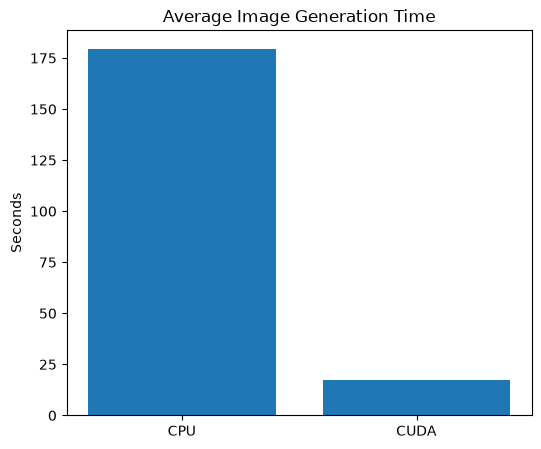

In [18]:
avg_time = (
    results_df
    .groupby("Device")["Generation_Time_Seconds"]
    .mean()
)

plt.figure(figsize=(6,5))

plt.bar(avg_time.index, avg_time.values)

plt.title("Average Image Generation Time")
plt.ylabel("Seconds")

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "generation_time_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Average Energy Consumption

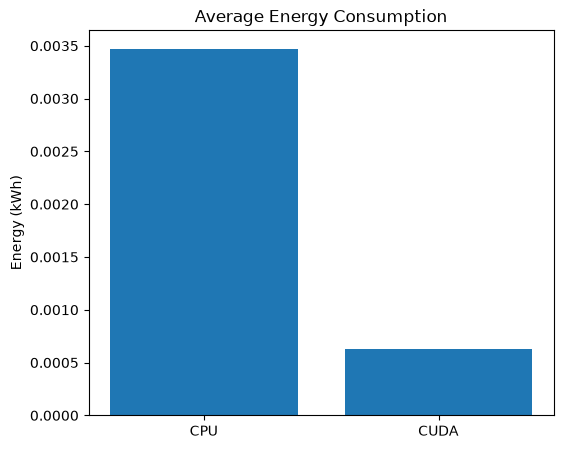

In [19]:
avg_energy = (
    results_df
    .groupby("Device")["Energy_kWh"]
    .mean()
)

plt.figure(figsize=(6,5))

plt.bar(avg_energy.index, avg_energy.values)

plt.title("Average Energy Consumption")
plt.ylabel("Energy (kWh)")

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "energy_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Average Carbon Emissions

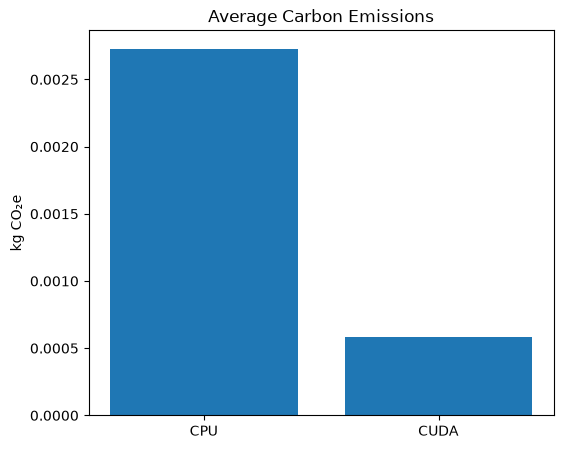

In [20]:
avg_carbon = (
    results_df
    .groupby("Device")["Carbon_kgCO2"]
    .mean()
)

plt.figure(figsize=(6,5))

plt.bar(avg_carbon.index, avg_carbon.values)

plt.title("Average Carbon Emissions")
plt.ylabel("kg CO₂e")

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "carbon_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Combined Comparison Table

In [21]:
comparison = (
    results_df
    .groupby("Device")
    .agg({
        "Generation_Time_Seconds":"mean",
        "Energy_kWh":"mean",
        "Carbon_kgCO2":"mean"
    })
    .round(6)
)

comparison

,Generation_Time_Seconds,Energy_kWh,Carbon_kgCO2
Device,,,
CPU,179.571,0.003472,0.002729
CUDA,17.500,0.000628,0.000585


# Percentage

In [22]:
cpu = comparison.loc["CPU"]
gpu = comparison.loc["CUDA"]

time_reduction = (
    (cpu["Generation_Time_Seconds"] - gpu["Generation_Time_Seconds"])
    / cpu["Generation_Time_Seconds"]
) * 100

energy_reduction = (
    (cpu["Energy_kWh"] - gpu["Energy_kWh"])
    / cpu["Energy_kWh"]
) * 100

carbon_reduction = (
    (cpu["Carbon_kgCO2"] - gpu["Carbon_kgCO2"])
    / cpu["Carbon_kgCO2"]
) * 100

print(f"Time Reduction   : {time_reduction:.2f}%")
print(f"Energy Reduction : {energy_reduction:.2f}%")
print(f"Carbon Reduction : {carbon_reduction:.2f}%")

Time Reduction   : 90.25%
Energy Reduction : 81.91%
Carbon Reduction : 78.56%


# Save Summary

In [23]:
comparison.to_csv(
    os.path.join(
        RESULT_DIR,
        "summary.csv"
    )
)

print("Summary saved successfully.")

Summary saved successfully.
